In [ ]:
scikit-learn
sklearn

In [6]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder

In [37]:
data = sns.load_dataset('iris')

X = data.drop(axis='columns', columns=['species'])
feature_names = X.columns
y = data.species
class_names = y.unique()

LE = LabelEncoder()
y = LE.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.25,
                                                    random_state = 0)

dt = DecisionTreeClassifier(max_depth = 4)
dt.fit(X_train, y_train)

print(dt.score(X_test, y_test))


# display(y_test)
# display(dt.predict(X_test))

0.9736842105263158


[Text(0.375, 0.875, 'petal_width <= 0.8\ngini = 0.665\nsamples = 112\nvalue = [37, 34, 41]\nclass = virginica'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 37\nvalue = [37, 0, 0]\nclass = setosa'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'petal_length <= 4.95\ngini = 0.496\nsamples = 75\nvalue = [0, 34, 41]\nclass = virginica'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'petal_width <= 1.65\ngini = 0.153\nsamples = 36\nvalue = [0, 33, 3]\nclass = versicolor'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 32\nvalue = [0, 32, 0]\nclass = versicolor'),
 Text(0.375, 0.125, 'gini = 0.375\nsamples = 4\nvalue = [0, 1, 3]\nclass = virginica'),
 Text(0.75, 0.375, 'petal_width <= 1.75\ngini = 0.05\nsamples = 39\nvalue = [0, 1, 38]\nclass = virginica'),
 Text(0.625, 0.125, 'gini = 0.375\nsamples = 4\nvalue = [0, 1, 3]\nclass = virginica'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 35\nvalue = [0, 0, 35]\nclass = virginica')]

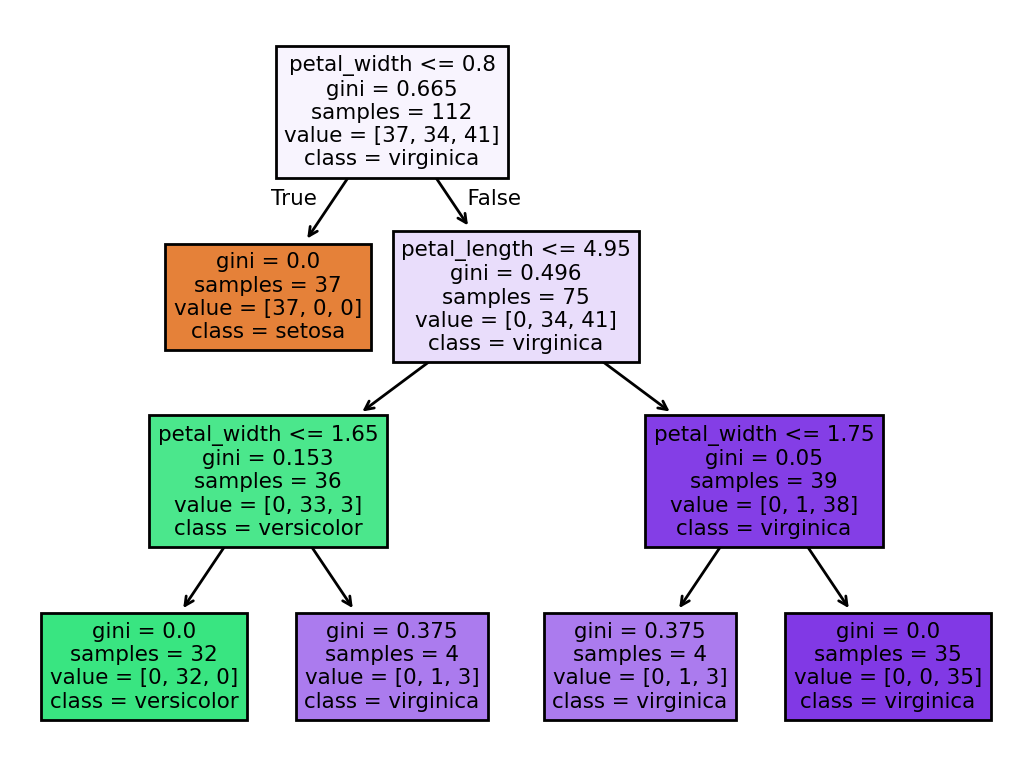

In [18]:
figure = plt.figure(dpi = 200)

plot_tree(dt,
          feature_names=feature_names,
          class_names = class_names,
          filled = True)

In [39]:
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [42]:
logistic = LogisticRegression()

X_log = data.loc[:,['sepal_length', 'petal_length']]
X_log_train, X_log_test, y_train, y_test = train_test_split(X_log,
                                                            y,
                                                            test_size = 0.25,
                                                            random_state = 0)
logistic.fit(X_log_train, y_train)

logistic.score(X_log_test, y_test)

0.9473684210526315

In [44]:
X_log

,sepal_length,petal_length
0,5.1,1.4
1,4.9,1.4
2,4.7,1.3
3,4.6,1.5
4,5.0,1.4
...,...,...
145,6.7,5.2
146,6.3,5.0
147,6.5,5.2
148,6.2,5.4


In [47]:
from sklearn.inspection import DecisionBoundaryDisplay

<Axes: xlabel='sepal_length', ylabel='petal_length'>

<Figure size 640x480 with 0 Axes>

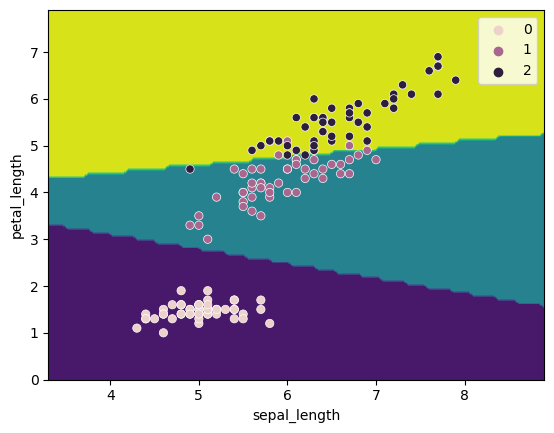

In [49]:
plt.figure()

DecisionBoundaryDisplay.from_estimator(logistic,
                                       X_log,
                                       response_method = 'predict')

sns.scatterplot(x = X_log.to_numpy()[:,0],
                y = X_log.to_numpy()[:,1],
                hue = y)